This notebook is for the cost calculation of the Economic Consequences of Nurse Staffing Decisions in Pandemic Hospital Systems Project

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# Load and clean data
df = pd.read_csv("Alberta Final Data 1 - infected_nurses.csv")
df.columns = df.columns.str.strip()
df = df.dropna(how="all")

In [21]:
# Split waves
wave1 = df.iloc[1:21].copy().reset_index(drop=True)
wave1.columns = ["Week", "New_Infections"]

wave2 = df.iloc[23:30].copy().reset_index(drop=True)
wave2.columns = ["Week", "New_Infections"]

In [22]:
# Convert to numeric
wave1["New_Infections"] = pd.to_numeric(wave1["New_Infections"], errors="coerce")
wave2["New_Infections"] = pd.to_numeric(wave2["New_Infections"], errors="coerce")

In [23]:
# Parameters
BASE_HOURLY = 47.38
OT_HOURS = 20      # 0.5 FTE
RD_HOURS = 40      # 1 FTE

COT = BASE_HOURLY * 1.5  # OT rate
CST = BASE_HOURLY         # Redeployment rate

COT_w = COT * OT_HOURS     # weekly OT cost per nurse
CST_w = CST * RD_HOURS     # weekly redeployment cost per nurse

In [24]:
# Cost calculation function
def calculate_weekly_cost(df):
    out = df.copy()
    AI = out["New_Infections"]

    out["Cost_0"] = AI * 2 * COT_w           # 0% redeployment: all OT (0.5 FTE per OT nurse)
    out["Cost_05"] = AI * (COT_w + 0.5* CST_w)  # 50% redeployment: average of OT and RD
    out["Cost_1"] = AI * CST_w               # 100% redeployment

    return out[["Week", "New_Infections", "Cost_0", "Cost_05", "Cost_1"]]


In [25]:
wave1_costs = calculate_weekly_cost(wave1)
wave1_costs

,Week,New_Infections,Cost_0,Cost_05,Cost_1
0,20-21,2.8869,8206.87932,6839.0661,5471.25288
1,21-22,4.7925,13624.11900,11353.4325,9082.74600
2,22-23,6.0957,17328.85596,14440.7133,11552.57064
3,23-24,7.0312,19988.29536,16656.9128,13325.53024
4,24-25,7.7419,22008.67332,18340.5611,14672.44888
5,25-26,8.3131,23632.48068,19693.7339,15754.98712
6,26-27,8.8007,25018.62996,20848.8583,16679.08664
7,27-28,9.2426,26274.86328,21895.7194,17516.57552
8,28-29,9.6556,27448.93968,22874.1164,18299.29312
9,29-30,10.0574,28591.17672,23825.9806,19060.78448


In [26]:
wave1_costs.to_csv("wave1_costs.csv", index=False)

In [27]:
wave2_costs = calculate_weekly_cost(wave2)
wave2_costs

,Week,New_Infections,Cost_0,Cost_05,Cost_1
0,91-92,131.3746,3.734717e+05,311226.4274,248981.14192
1,92-93,214.2678,6.091205e+05,507600.4182,406080.33456
2,93-94,267.4039,7.601758e+05,633479.8391,506783.87128
3,94-95,303.8044,8.636551e+05,719712.6236,575770.09888
4,95-96,332.3866,9.449086e+05,787423.8554,629939.08432
5,96-97,357.2265,1.015523e+06,846269.5785,677015.66280


In [28]:
wave2_costs.to_csv("wave2_costs.csv", index=False)

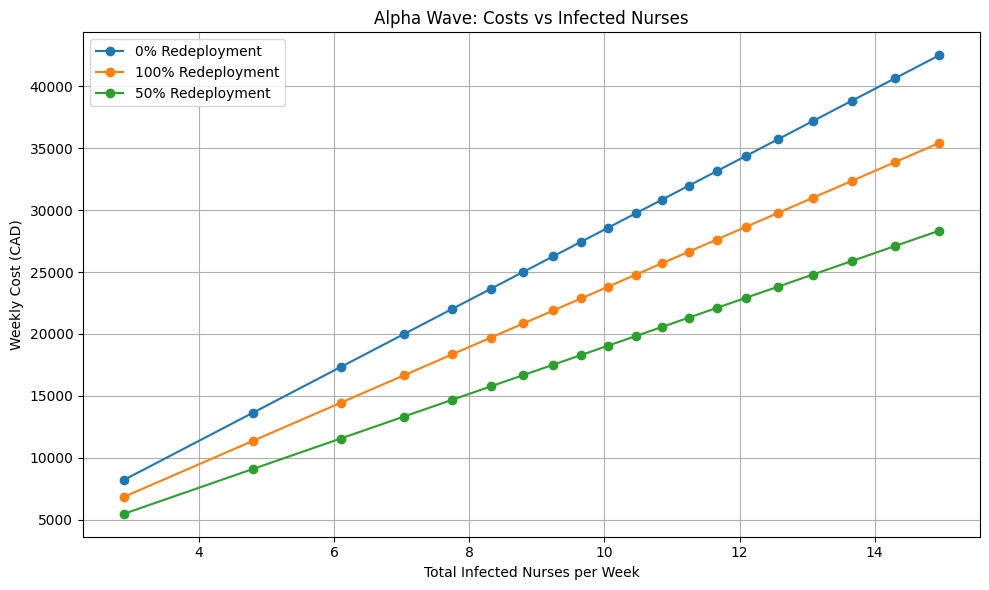

In [30]:
# --- Wave 1 Cost Visualization ---
plt.figure(figsize=(10,6))
plt.plot(wave1_costs["New_Infections"], wave1_costs["Cost_0"], marker="o", label="0% Redeployment")
plt.plot(wave1_costs["New_Infections"], wave1_costs["Cost_05"], marker="o", label="100% Redeployment")
plt.plot(wave1_costs["New_Infections"], wave1_costs["Cost_1"], marker="o", label="50% Redeployment")

plt.xlabel("Total Infected Nurses per Week")
plt.ylabel("Weekly Cost (CAD)")
plt.title("Alpha Wave: Costs vs Infected Nurses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

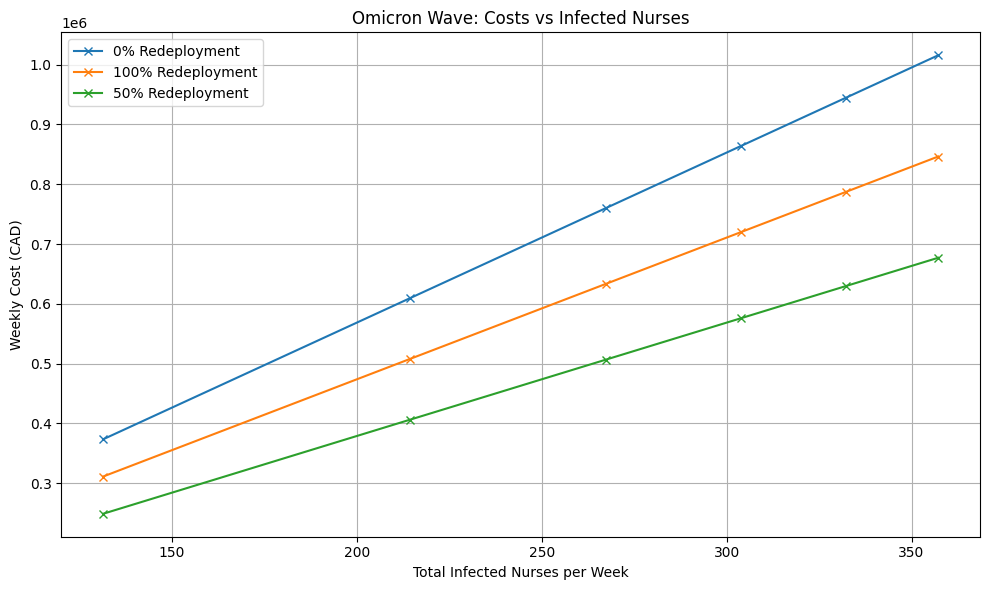

In [31]:
# --- Wave 2 Cost Visualization ---
plt.figure(figsize=(10,6))
plt.plot(wave2_costs["New_Infections"], wave2_costs["Cost_0"], marker="x", label="0% Redeployment")
plt.plot(wave2_costs["New_Infections"], wave2_costs["Cost_05"], marker="x", label="100% Redeployment")
plt.plot(wave2_costs["New_Infections"], wave2_costs["Cost_1"], marker="x", label="50% Redeployment")

plt.xlabel("Total Infected Nurses per Week")
plt.ylabel("Weekly Cost (CAD)")
plt.title("Omicron Wave: Costs vs Infected Nurses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

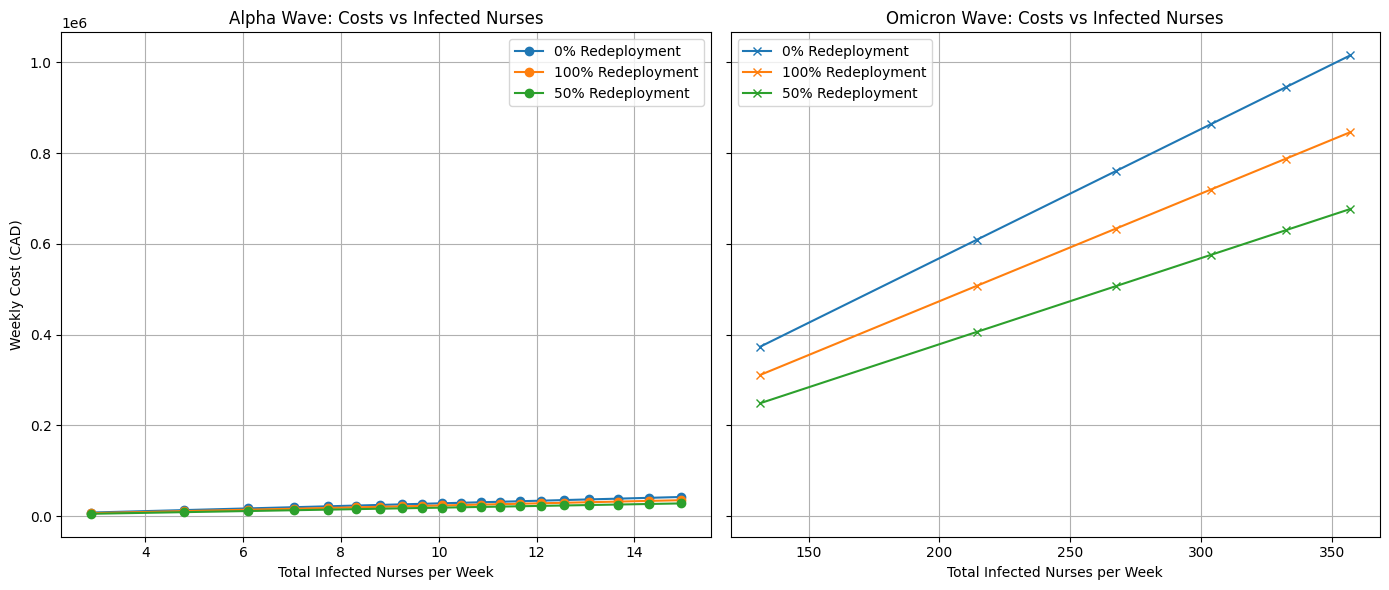

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# --- Wave 1 ---
axs[0].plot(wave1_costs["New_Infections"], wave1_costs["Cost_0"], marker="o", label="0% Redeployment")
axs[0].plot(wave1_costs["New_Infections"], wave1_costs["Cost_05"], marker="o", label="100% Redeployment")
axs[0].plot(wave1_costs["New_Infections"], wave1_costs["Cost_1"], marker="o", label="50% Redeployment")

axs[0].set_title("Alpha Wave: Costs vs Infected Nurses")
axs[0].set_xlabel("Total Infected Nurses per Week")
axs[0].set_ylabel("Weekly Cost (CAD)")
axs[0].grid(True)
axs[0].legend()

# --- Wave 2 ---
axs[1].plot(wave2_costs["New_Infections"], wave2_costs["Cost_0"], marker="x", label="0% Redeployment")
axs[1].plot(wave2_costs["New_Infections"], wave2_costs["Cost_05"], marker="x", label="100% Redeployment")
axs[1].plot(wave2_costs["New_Infections"], wave2_costs["Cost_1"], marker="x", label="50% Redeployment")

axs[1].set_title("Omicron Wave: Costs vs Infected Nurses")
axs[1].set_xlabel("Total Infected Nurses per Week")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# --- Function to calculate OT requirements with rounding ---
def calculate_overtime(df, p_redeploy=0):
    """
    p_redeploy: 0 (0%) or 0.5 (50%)
    """
    out = df.copy()
    AI = out["New_Infections"]

    # Total OT hours
    total_ot_hours = AI * (1 - p_redeploy) * 2 * OT_HOURS  # 0.5 FTE per OT nurse → *2

    # Nurses required
    out["Total_OT_Hours"] = total_ot_hours.round(0).astype(int)
    out["Nurses_4h"] = (total_ot_hours / 4).round(0).astype(int)
    out["Nurses_8h"] = (total_ot_hours / 8).round(0).astype(int)
    out["Nurses_20h"] = (total_ot_hours / 20).round(0).astype(int)

    return out[["Week", "New_Infections", "Total_OT_Hours", "Nurses_4h", "Nurses_8h", "Nurses_20h"]]


In [ ]:
# Apply for 0% redeployment
wave1_ot_0 = calculate_overtime(wave1, p_redeploy=0)
wave1_ot_0

,Week,New_Infections,Total_OT_Hours,Nurses_4h,Nurses_8h,Nurses_20h
0,20-21,2.8869,115,29,14,6
1,21-22,4.7925,192,48,24,10
2,22-23,6.0957,244,61,30,12
3,23-24,7.0312,281,70,35,14
4,24-25,7.7419,310,77,39,15
5,25-26,8.3131,333,83,42,17
6,26-27,8.8007,352,88,44,18
7,27-28,9.2426,370,92,46,18
8,28-29,9.6556,386,97,48,19
9,29-30,10.0574,402,101,50,20


In [ ]:
wave1_ot_0.to_csv("wave1_ot_0.csv", index=False)

In [ ]:
wave2_ot_0 = calculate_overtime(wave2, p_redeploy=0)
wave2_ot_0

,Week,New_Infections,Total_OT_Hours,Nurses_4h,Nurses_8h,Nurses_20h
0,91-92,131.3746,5255,1314,657,263
1,92-93,214.2678,8571,2143,1071,429
2,93-94,267.4039,10696,2674,1337,535
3,94-95,303.8044,12152,3038,1519,608
4,95-96,332.3866,13295,3324,1662,665
5,96-97,357.2265,14289,3572,1786,714


In [ ]:
wave2_ot_0.to_csv("wave2_ot_0.csv", index=False)

In [ ]:
# Apply for 50% redeployment
wave1_ot_05 = calculate_overtime(wave1, p_redeploy=0.5)
wave1_ot_05

,Week,New_Infections,Total_OT_Hours,Nurses_4h,Nurses_8h,Nurses_20h
0,20-21,2.8869,58,14,7,3
1,21-22,4.7925,96,24,12,5
2,22-23,6.0957,122,30,15,6
3,23-24,7.0312,141,35,18,7
4,24-25,7.7419,155,39,19,8
5,25-26,8.3131,166,42,21,8
6,26-27,8.8007,176,44,22,9
7,27-28,9.2426,185,46,23,9
8,28-29,9.6556,193,48,24,10
9,29-30,10.0574,201,50,25,10


In [ ]:
wave1_ot_05.to_csv("wave1_ot_05.csv", index=False)

In [ ]:
wave2_ot_05 = calculate_overtime(wave2, p_redeploy=0.5)
wave2_ot_05

,Week,New_Infections,Total_OT_Hours,Nurses_4h,Nurses_8h,Nurses_20h
0,91-92,131.3746,2627,657,328,131
1,92-93,214.2678,4285,1071,536,214
2,93-94,267.4039,5348,1337,669,267
3,94-95,303.8044,6076,1519,760,304
4,95-96,332.3866,6648,1662,831,332
5,96-97,357.2265,7145,1786,893,357


In [ ]:
wave2_ot_05.to_csv("wave_ot_05.csv", index=False)

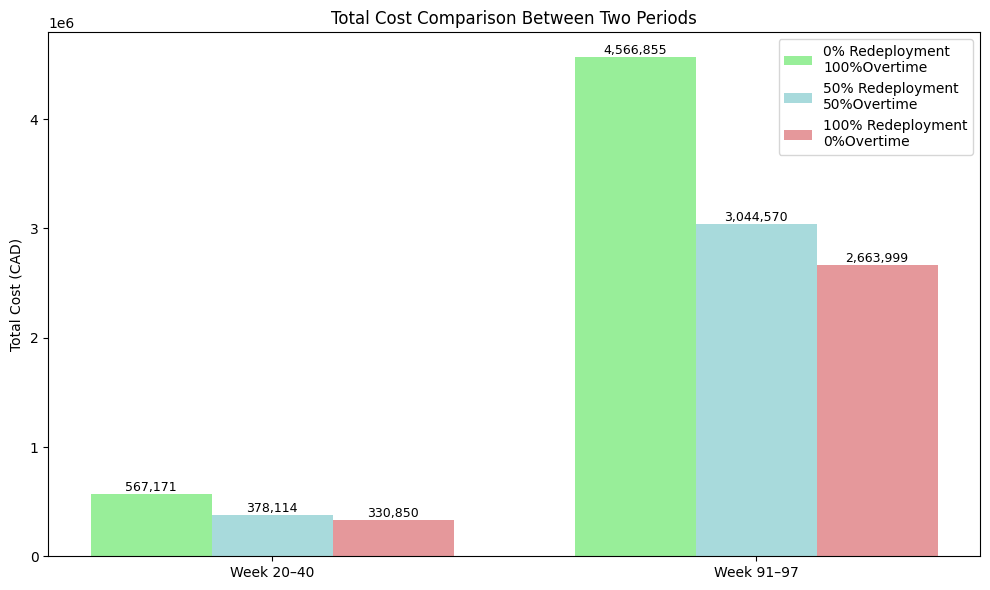

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
scenarios = ["0% Redeployment\n100%Overtime",
             "50% Redeployment\n50%Overtime",
             "100% Redeployment\n0%Overtime"]
week_20_40 = np.array([567171, 378114, 330850])
week_91_97 = np.array([4566855, 3044570, 2663999])

# Colors: mint green, nude blue, nude red
colors = ["#98ee99", "#A8DADC", "#E5989B"]

# Bar positions
n_scenarios = len(scenarios)
n_periods = 2
width = 0.25  # width of each bar

# x positions for each period
x = np.arange(n_periods)

# Create figure
plt.figure(figsize=(10,6))

# Plot bars for each scenario
for i in range(n_scenarios):
    plt.bar(x + (i - 1) * width,
            [week_20_40[i], week_91_97[i]],
            width, label=scenarios[i], color=colors[i])

# Labels and title
plt.ylabel("Total Cost (CAD)")
plt.title("Total Cost Comparison Between Two Periods")
plt.xticks(x, ["Week 20–40", "Week 91–97"])
plt.legend()

# Add value labels
for i in range(n_scenarios):
    for j, val in enumerate([week_20_40[i], week_91_97[i]]):
        plt.text(x[j] + (i - 1) * width, val, f'{int(val):,}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


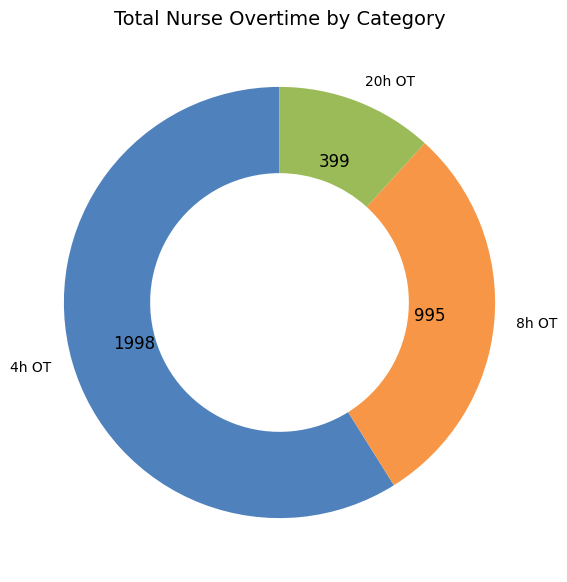

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ['4h OT', '8h OT', '20h OT']
totals = [1998, 995, 399] #wave 1 100%ot

colors = ['#4F81BD',  # Deep Blue
          '#F79646',  # Soft Orange
          '#9BBB59']  # Muted Green


# --- Donut Chart with Exact Numbers ---
plt.figure(figsize=(7,7))
wedges, texts = plt.pie(
    totals,
    labels=categories,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.4)  # creates the donut hole
)

# Add exact numbers inside slices
for i, w in enumerate(wedges):
    # Compute angle of wedge
    angle = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(angle)) * 0.7   # radius factor for text position
    y = np.sin(np.deg2rad(angle)) * 0.7
    plt.text(x, y, str(totals[i]), ha='center', va='center', fontsize=12, color='black')

plt.title("Total Nurse Overtime by Category", fontsize=14)
plt.show()


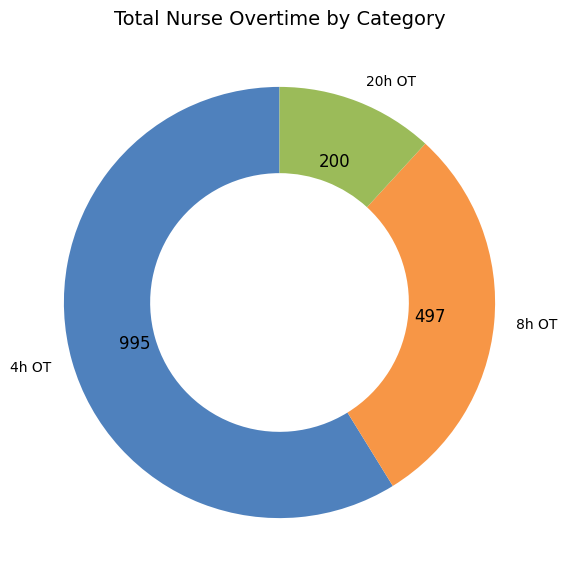

In [ ]:
# Data
categories = ['4h OT', '8h OT', '20h OT']
totals = [995, 497, 200] #wave 1 50%ot


colors = ['#4F81BD',  # Deep Blue
          '#F79646',  # Soft Orange
          '#9BBB59']  # Muted Green

# --- Donut Chart with Exact Numbers ---
plt.figure(figsize=(7,7))
wedges, texts = plt.pie(
    totals,
    labels=categories,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.4)  # creates the donut hole
)

# Add exact numbers inside slices
for i, w in enumerate(wedges):
    # Compute angle of wedge
    angle = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(angle)) * 0.7   # radius factor for text position
    y = np.sin(np.deg2rad(angle)) * 0.7
    plt.text(x, y, str(totals[i]), ha='center', va='center', fontsize=12, color='black')

plt.title("Total Nurse Overtime by Category", fontsize=14)
plt.show()


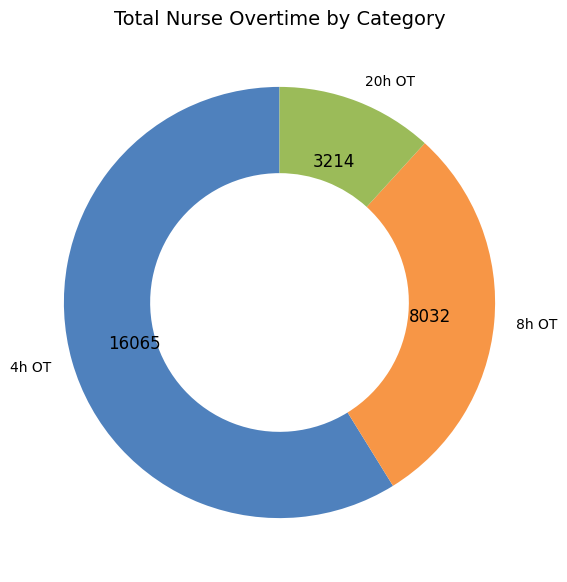

In [ ]:
# Data
categories = ['4h OT', '8h OT', '20h OT']
totals = [16065, 8032, 3214] #wave 2 100%ot


colors = ['#4F81BD',  # Deep Blue
          '#F79646',  # Soft Orange
          '#9BBB59']  # Muted Green

# --- Donut Chart with Exact Numbers ---
plt.figure(figsize=(7,7))
wedges, texts = plt.pie(
    totals,
    labels=categories,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.4)  # creates the donut hole
)

# Add exact numbers inside slices
for i, w in enumerate(wedges):
    # Compute angle of wedge
    angle = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(angle)) * 0.7   # radius factor for text position
    y = np.sin(np.deg2rad(angle)) * 0.7
    plt.text(x, y, str(totals[i]), ha='center', va='center', fontsize=12, color='black')

plt.title("Total Nurse Overtime by Category", fontsize=14)
plt.show()


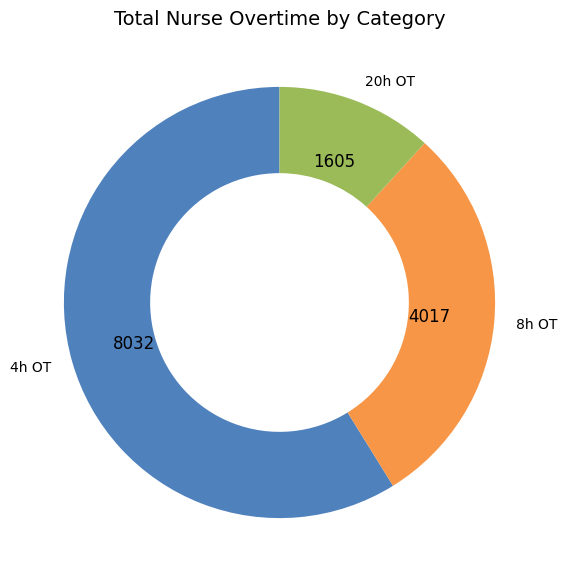

In [ ]:
# Data
categories = ['4h OT', '8h OT', '20h OT']
totals = [8032, 4017, 1605] #wave 1 50%ot

colors = ['#4F81BD',  # Deep Blue
          '#F79646',  # Soft Orange
          '#9BBB59']  # Muted Green

# --- Donut Chart with Exact Numbers ---
plt.figure(figsize=(7,7))
wedges, texts = plt.pie(
    totals,
    labels=categories,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.4)  # creates the donut hole
)

# Add exact numbers inside slices
for i, w in enumerate(wedges):
    # Compute angle of wedge
    angle = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(angle)) * 0.7   # radius factor for text position
    y = np.sin(np.deg2rad(angle)) * 0.7
    plt.text(x, y, str(totals[i]), ha='center', va='center', fontsize=12, color='black')

plt.title("Total Nurse Overtime by Category", fontsize=14)
plt.show()
